# Quran Translation — Exploratory Data Analysis

Analysis of the **English Saheeh International** translation (`translation_id=20`)
of the Quran, 6,236 verses across 114 chapters.

> **Scope note:** all findings describe an *English translation*, not the Arabic
> source text. Word counts, frequencies, and lengths are properties of the
> translation's prose.

Analysis logic lives in the reusable `quran_analysis` package; this notebook is a
thin presentation layer over `quran_analysis.eda` and `quran_analysis.text`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

# Resolve repo root by walking up to the directory containing data/, so the
# notebook works whether launched from repo root or notebooks/.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data").is_dir())
sys.path.insert(0, str(ROOT / "src"))

from quran_analysis import eda

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = eda.load_verses(ROOT / "data/processed/verses_translation_20.parquet")
df.shape

(6236, 27)

In [2]:
# Derived text columns:
#   clean_text       - footnotes/markup stripped, KEEPS [translator interpolations]
#   scripture_text   - interpolations removed (directly-rendered words only)
#   word_count / scripture_word_count - token counts for each variant
df[["verse_key", "clean_text", "scripture_text", "word_count", "scripture_word_count"]].head()

,verse_key,clean_text,scripture_text,word_count,scripture_word_count
0,1:1,"In the name of Allāh, the Entirely Merciful, t...","In the name of Allāh, the Entirely Merciful, t...",11,11
1,1:2,"All praise is due to Allāh, Lord of the worlds -","praise is to Allāh, Lord of the worlds -",10,8
2,1:3,"The Entirely Merciful, the Especially Merciful,","The Entirely Merciful, the Especially Merciful,",6,6
3,1:4,Sovereign of the Day of Recompense.,Sovereign of the Day of Recompense.,6,6
4,1:5,It is You we worship and You we ask for help.,It is You we worship and You we ask for help.,11,11


## Area 1 — Data Quality

Establish that the dataset is complete and understand its text-cleaning needs
before measuring anything.

In [3]:
# Headline integrity checks.
eda.data_quality_report(df)

total_verses                  6236
unique_chapters                114
null_translation                 0
empty_translation                0
duplicate_translation_text     126
verses_with_footnotes         1612
total_footnotes               1903
verses_with_brackets          3409
Name: data_quality, dtype: int64

In [4]:
# Verse counts per chapter vs the chapter metadata's expected count.
# An empty result below means every chapter has exactly the expected verses.
integrity = eda.verse_count_integrity(df)
mismatches = integrity.loc[~integrity["matches"]]
print(f"{len(mismatches)} / {len(integrity)} chapters mismatch expected verse counts")
mismatches

0 / 114 chapters mismatch expected verse counts


,chapter_id,chapter_name_simple,expected_verses,observed_verses,matches


In [5]:
# The 126 "duplicate" verse texts are legitimate refrains, not data errors.
# Ar-Rahman's recurring rhetorical question dominates.
eda.duplicate_examples(df).head(8)[["repeats", "verse_keys", "clean_text"]]

,repeats,verse_keys,clean_text
0,24,"[55:13, 55:16, 55:18, 55:21, 55:23, 55:25, 55:...",So which of the favors of your Lord would you ...
1,10,"[77:15, 77:19, 77:24, 77:28, 77:34, 77:37, 77:...","Woe, that Day, to the deniers."
2,8,"[26:9, 26:68, 26:104, 26:122, 26:140, 26:159, ...","And indeed, your Lord - He is the Exalted in M..."
3,7,"[55:38, 55:47, 55:57, 55:63, 55:71, 55:73, 55:75]",So which of the favors of your Lord would you ...
4,7,"[40:1, 41:1, 42:1, 43:1, 44:1, 45:1, 46:1]","Ḥā, Meem."
5,7,"[26:108, 26:126, 26:131, 26:144, 26:150, 26:16...",So fear Allāh and obey me.
6,6,"[26:8, 26:67, 26:103, 26:121, 26:174, 26:190]","Indeed in that is a sign, but most of them wer..."
7,6,"[2:1, 3:1, 29:1, 30:1, 31:1, 32:1]","Alif, Lām, Meem."


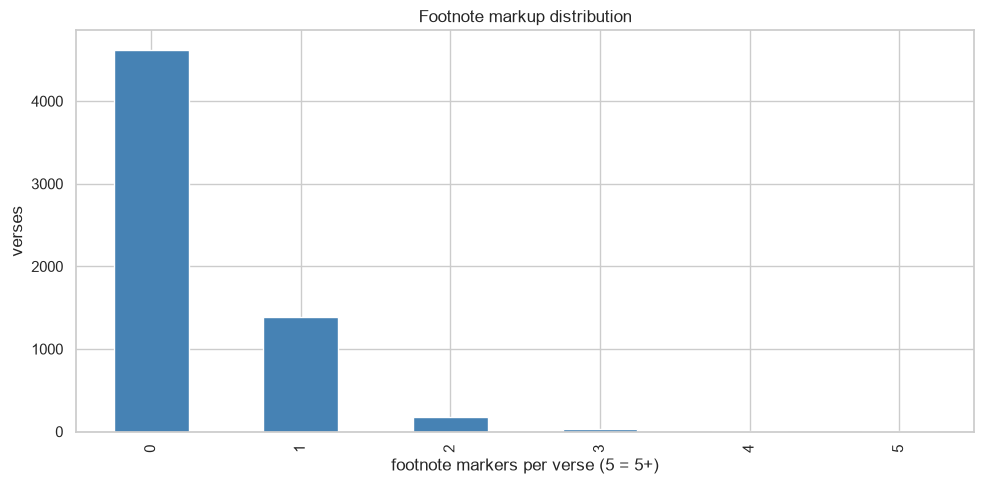

In [6]:
# Footnote markup coverage (now stripped from clean_text).
ax = (
    df["footnote_count"].clip(upper=5)
    .value_counts().sort_index()
    .plot(kind="bar", color="steelblue")
)
ax.set(xlabel="footnote markers per verse (5 = 5+)", ylabel="verses",
       title="Footnote markup distribution")
plt.tight_layout()

In [7]:
# Translator interpolations: 55% of verses contain [bracketed] clarifications,
# adding ~6.5% to the total word count. We keep both variants so each downstream
# analysis can choose its basis.
total = df["word_count"].sum()
scripture = df["scripture_word_count"].sum()
print(f"With interpolations : {total:,} words")
print(f"Scripture-only      : {scripture:,} words")
print(f"Interpolations add  : {total - scripture:,} words ({(total - scripture) / total:.1%})")

With interpolations : 159,867 words
Scripture-only      : 149,553 words
Interpolations add  : 10,314 words (6.5%)


**Area 1 takeaways**

- Dataset is **complete and clean**: 6,236 verses, 114 chapters, zero verse-count
  mismatches, no null/empty translations.
- Two cleaning concerns handled: `<sup>` footnote markup (1,612 verses) and
  `[bracketed]` translator interpolations (55% of verses, ~6.5% of words).
- "Duplicate" texts are real refrains (e.g. Ar-Rahman ×24), not errors.